# Netflix Content Strategy Analysis

This notebook provides a comprehensive analysis of Netflix's content strategy, including genre distribution, release patterns, and market positioning.

## Table of Contents
1. [Data Import and Preprocessing](#data-import)
2. [Exploratory Data Analysis](#eda)
3. [Content Distribution Analysis](#content-analysis)
4. [Genre and Rating Patterns](#genre-analysis)
5. [Temporal Trends](#temporal-analysis)
6. [Geographic Analysis](#geographic-analysis)
7. [Strategic Insights](#insights)
8. [Conclusions and Recommendations](#conclusions)

## 1. Data Import and Preprocessing {#data-import}

Import necessary libraries and load the Netflix dataset.

In [ ]:
# Import required libraries
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# load the dataset
netflix_data = pd.read_csv("netflix_content.csv")

In [4]:
# remove commas and convert to float
netflix_data['Hours Viewed'] = (
    netflix_data['Hours Viewed']
    .str.replace(',', '', regex=True)
    .astype(float)
)

# preview
netflix_data[['Title', 'Hours Viewed']].head()

,Title,Hours Viewed
0,The Night Agent: Season 1,812100000.0
1,Ginny & Georgia: Season 2,665100000.0
2,The Glory: Season 1 // 더 글로리: 시즌 1,622800000.0
3,Wednesday: Season 1,507700000.0
4,Queen Charlotte: A Bridgerton Story,503000000.0


## 2. Exploratory Data Analysis {#eda}

Basic exploration of the Netflix content dataset.

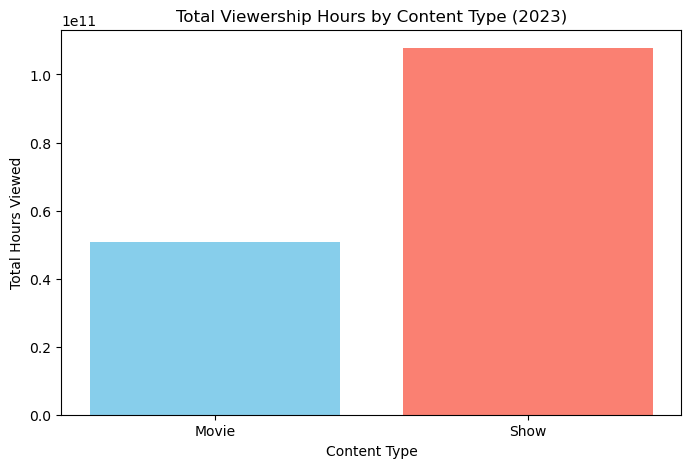

In [5]:
# aggregate total hours viewed
content_type_viewership = (
    netflix_data.groupby('Content Type')['Hours Viewed']
    .sum()
)

# bar plot
plt.figure(figsize=(8, 5))
plt.bar(
    content_type_viewership.index,
    content_type_viewership.values,
    color=['skyblue', 'salmon']
)
plt.title('Total Viewership Hours by Content Type (2023)')
plt.xlabel('Content Type')
plt.ylabel('Total Hours Viewed')
plt.show()

## 3. Content Distribution Analysis {#content-analysis}

Analysis of Netflix content types, genres, and distribution patterns.

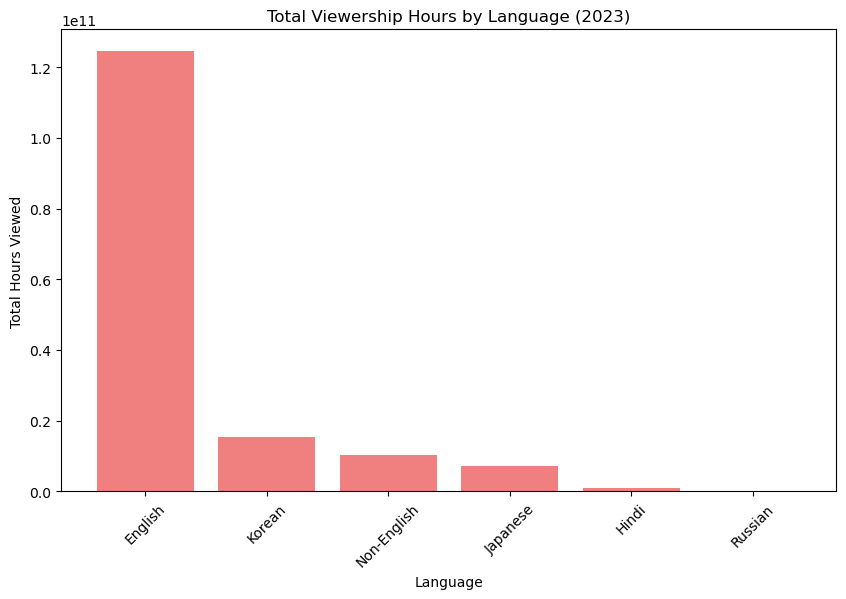

In [6]:
language_viewership = (
    netflix_data.groupby('Language Indicator')['Hours Viewed']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(
    language_viewership.index,
    language_viewership.values,
    color='lightcoral'
)
plt.title('Total Viewership Hours by Language (2023)')
plt.xlabel('Language')
plt.ylabel('Total Hours Viewed')
plt.xticks(rotation=45)
plt.show()

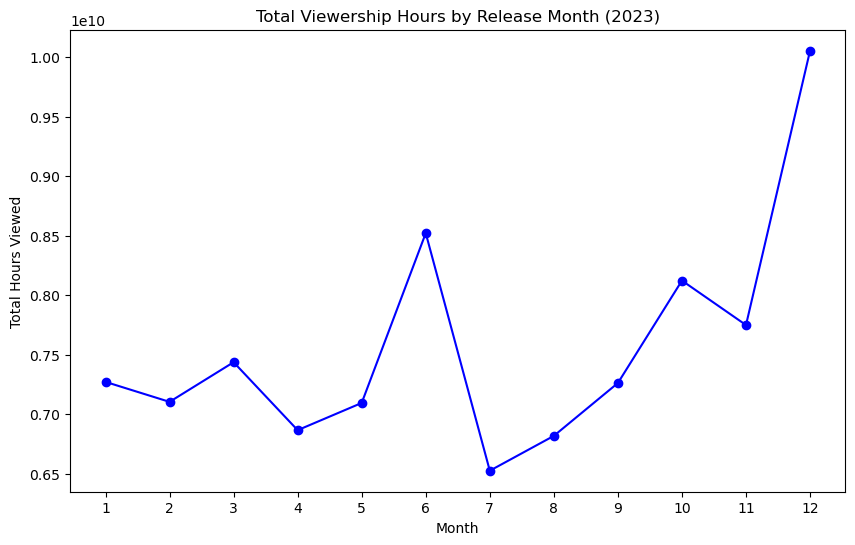

In [7]:
# convert release date
netflix_data['Release Date'] = pd.to_datetime(netflix_data['Release Date'])
netflix_data['Release Month'] = netflix_data['Release Date'].dt.month

monthly_viewership = (
    netflix_data.groupby('Release Month')['Hours Viewed']
    .sum()
)

plt.figure(figsize=(10, 6))
plt.plot(
    monthly_viewership.index,
    monthly_viewership.values,
    marker='o',
    linestyle='-',
    color='blue'
)
plt.title('Total Viewership Hours by Release Month (2023)')
plt.xlabel('Month')
plt.ylabel('Total Hours Viewed')
plt.xticks(ticks=range(1, 13))
plt.show()

In [8]:
top_5_titles = netflix_data.nlargest(5, 'Hours Viewed')

top_5_titles[['Title', 'Hours Viewed', 'Language Indicator', 'Content Type', 'Release Date']]

,Title,Hours Viewed,Language Indicator,Content Type,Release Date
0,The Night Agent: Season 1,812100000.0,English,Show,2023-03-23
1,Ginny & Georgia: Season 2,665100000.0,English,Show,2023-01-05
18227,King the Land: Limited Series // 킹더랜드: 리미티드 시리즈,630200000.0,Korean,Movie,2023-06-17
2,The Glory: Season 1 // 더 글로리: 시즌 1,622800000.0,Korean,Show,2022-12-30
18214,ONE PIECE: Season 1,541900000.0,English,Show,2023-08-31


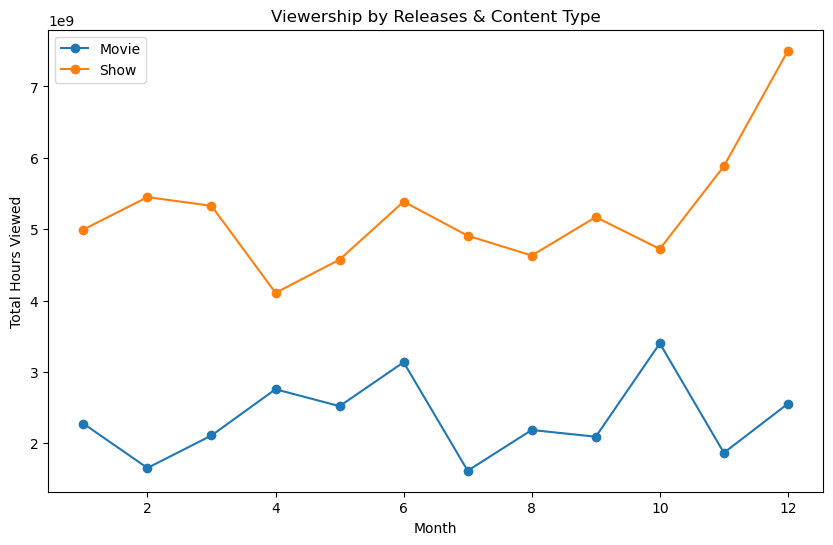

In [9]:
monthly_viewership_by_type = (
    netflix_data.pivot_table(
        index='Release Month',
        columns='Content Type',
        values='Hours Viewed',
        aggfunc='sum'
    )
)

plt.figure(figsize=(10, 6))
for col in monthly_viewership_by_type.columns:
    plt.plot(
        monthly_viewership_by_type.index,
        monthly_viewership_by_type[col],
        marker='o',
        label=col
    )
plt.title('Viewership by Releases & Content Type')
plt.xlabel('Month')
plt.ylabel('Total Hours Viewed')
plt.legend()
plt.show()

## 4. Conclusions and Strategic Insights {#conclusions}

Summary of key findings and strategic recommendations for Netflix's content strategy.

### Key Findings:
- [Add your key findings here based on the analysis]
- [Content strategy insights]
- [Market positioning observations]

### Strategic Recommendations:
- [Add strategic recommendations based on your analysis]
- [Future content strategy suggestions]
- [Market expansion opportunities]